In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib
from matplotlib import rcParams
from pathlib import Path
import numpy as np

# 设置中文字体支持
import matplotlib.font_manager as fm
# 备选中文字体列表
chinese_fonts = [
    "SimHei",           # Windows
    "Heiti TC",         # macOS
    "WenQuanYi Micro Hei",  # Linux
    "Microsoft YaHei",  # 微软雅黑
    "Arial Unicode MS", # 备选
]

# 获取系统可用字体
available_fonts = {f.name for f in fm.fontManager.ttflist}

# 查找第一个可用的中文字体
for font in chinese_fonts:
    if font in available_fonts:
        plt.rcParams["font.family"] = font
        break

plt.rcParams['axes.unicode_minus'] = False  # 解决负号显示问题

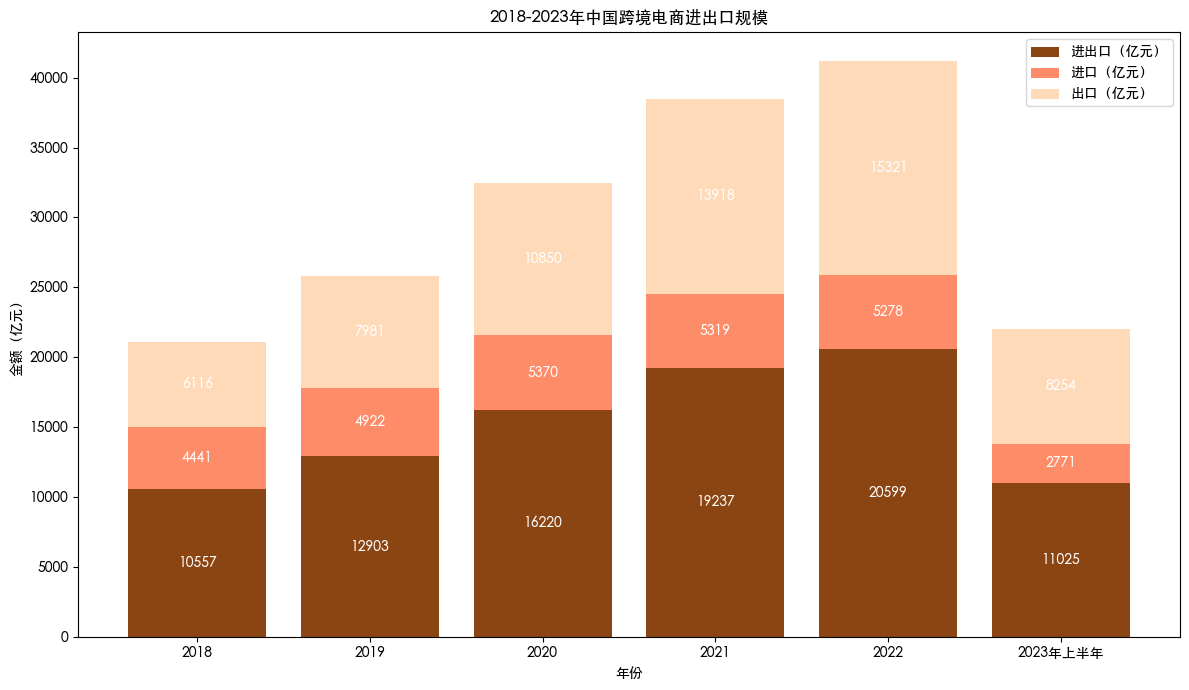

In [2]:
import matplotlib.pyplot as plt
import numpy as np

# 数据
years = ["2018", "2019", "2020", "2021", "2022", "2023年上半年"]
export = [6116, 7981, 10850, 13918, 15321, 8254]  # 出口（亿元）
import_ = [4441, 4922, 5370, 5319, 5278, 2771]    # 进口（亿元）
total = [10557, 12903, 16220, 19237, 20599, 11025] # 进出口（亿元）

x = np.arange(len(years))

fig, ax = plt.subplots(figsize=(12, 7))

# 绘制堆叠柱状图（从下到上：进出口、进口、出口 ，与原图顺序对应）
ax.bar(x, total, color='#8B4513', label='进出口（亿元）')
ax.bar(x, import_, bottom=total, color='#FF8C69', label='进口（亿元）')
ax.bar(x, export, bottom=np.array(total) + np.array(import_), color='#FFDAB9', label='出口（亿元）')

ax.set_ylabel('金额（亿元）')
ax.set_xlabel('年份')
ax.set_xticks(x)
ax.set_xticklabels(years)
ax.legend()
ax.set_title('2018-2023年中国跨境电商进出口规模')

# 添加数值标注（分别标注进出口、进口、出口的数值 ）
for i in range(len(years)):
    # 标注进出口数值
    ax.text(i, total[i] / 2, f'{total[i]}', ha='center', va='center', color='white', fontweight='bold')
    # 标注进口数值
    ax.text(i, total[i] + import_[i] / 2, f'{import_[i]}', ha='center', va='center', color='white', fontweight='bold')
    # 标注出口数值
    bottom_sum = total[i] + import_[i]
    ax.text(i, bottom_sum + export[i] / 2, f'{export[i]}', ha='center', va='center', color='white', fontweight='bold')

plt.tight_layout()
plt.show()

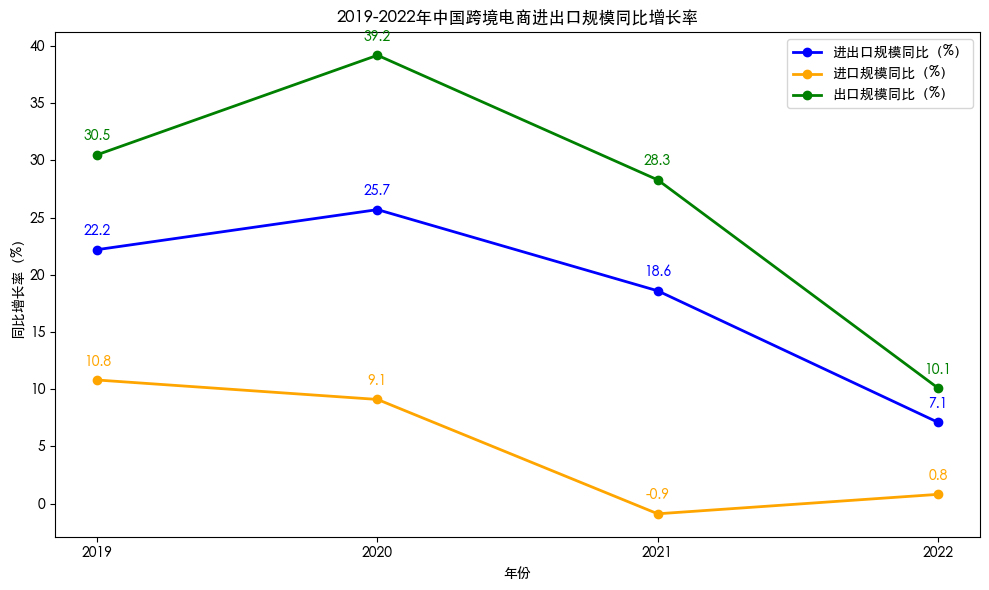

In [4]:
import matplotlib.pyplot as plt
import numpy as np

# 数据
years = ["2019", "2020", "2021", "2022"]
export_growth = [30.5, 39.2, 28.3, 10.1]  # 出口规模同比增长率（%）
import_growth = [10.8, 9.1, -0.9, 0.8]    # 进口规模同比增长率（%）
total_growth = [22.2, 25.7, 18.6, 7.1]    # 进出口规模同比增长率（%）

x = np.arange(len(years))

fig, ax = plt.subplots(figsize=(10, 6))

# 绘制折线图
ax.plot(x, total_growth, marker='o', color='blue', label='进出口规模同比（%）', linewidth=2)
ax.plot(x, import_growth, marker='o', color='orange', label='进口规模同比（%）', linewidth=2)
ax.plot(x, export_growth, marker='o', color='green', label='出口规模同比（%）', linewidth=2)

ax.set_ylabel('同比增长率（%）')
ax.set_xlabel('年份')
ax.set_xticks(x)
ax.set_xticklabels(years)
ax.legend()
ax.set_title('2019-2022年中国跨境电商进出口规模同比增长率')

# 添加数值标注
for i in range(len(years)):
    # 标注进出口规模同比数值
    ax.text(i, total_growth[i] + 1, f'{total_growth[i]}', ha='center', va='bottom', color='blue')
    # 标注进口规模同比数值
    ax.text(i, import_growth[i] + 1, f'{import_growth[i]}', ha='center', va='bottom', color='orange')
    # 标注出口规模同比数值
    ax.text(i, export_growth[i] + 1, f'{export_growth[i]}', ha='center', va='bottom', color='green')

plt.tight_layout()
plt.show()

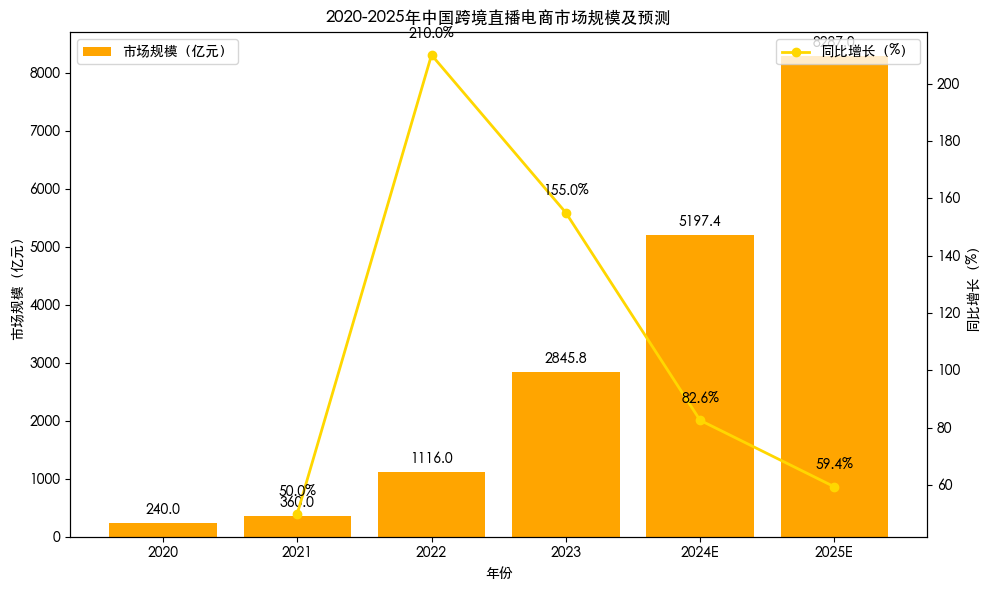

In [6]:
import matplotlib.pyplot as plt
import numpy as np

# 数据
years = ["2020", "2021", "2022", "2023", "2024E", "2025E"]
market_size = [240.0, 360.0, 1116.0, 2845.8, 5197.4, 8287.0]
growth_rate = [np.nan, 50.0, 210.0, 155.0, 82.6, 59.4]  # 2020年无同比数据，用np.nan标记

x = np.arange(len(years))

fig, ax1 = plt.subplots(figsize=(10, 6))

# 绘制市场规模柱状图
ax1.bar(x, market_size, color='orange', label='市场规模（亿元）')
ax1.set_ylabel('市场规模（亿元）')
ax1.set_xlabel('年份')
ax1.set_xticks(x)
ax1.set_xticklabels(years)
ax1.legend(loc='upper left')

# 创建双轴，绘制同比增长折线图
ax2 = ax1.twinx()
ax2.plot(x[1:], growth_rate[1:], marker='o', color='gold', label='同比增长（%）', linewidth=2)  # 2020年无同比数据，从2021开始
ax2.set_ylabel('同比增长（%）')
ax2.legend(loc='upper right')

# 添加市场规模数值标注
for i, size in enumerate(market_size):
    ax1.text(i, size + 100, f'{size}', ha='center', va='bottom')

# 添加同比增长数值标注（2020年无，从2021开始）
for i, rate in enumerate(growth_rate[1:], start=1):
    ax2.text(i, rate + 5, f'{rate}%', ha='center', va='bottom')

ax1.set_title('2020-2025年中国跨境直播电商市场规模及预测')

plt.tight_layout()
plt.show()